# Module 5 - Bullwhip Effect Quantification
## MedCore Pharma | Demand Planning Intelligence

Objective: Quantify the bullwhip effect per SKU by comparing the variance of
actual customer demand to the variance of the forecast/order signal propagated
upstream. A variance ratio > 1 indicates demand amplification (bullwhip).

Methodology:
- Variance ratio = Var(forecast signal) / Var(actual demand)
- Computed per SKU across the full 152-week history
- Ratio > 1 → bullwhip amplifier (flagged in Module 1 as has_bullwhip)
- Ratio ≈ 1 → no amplification

Stack:pandas, numpy, SQLite

In [8]:
# Cell 1 : Imports & Schema Check

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt


DB_PATH = os.path.join("..", "data", "medcore.db")
conn = sqlite3.connect(DB_PATH)

df_demand = pd.read_sql("SELECT * FROM demand_history", conn)
df_forecast = pd.read_sql("SELECT * FROM forecast_history", conn)

print("demand_history columns  :", list(df_demand.columns))
print("forecast_history columns:", list(df_forecast.columns))
print(f"\ndemand_history   : {len(df_demand)} rows")
print(f"forecast_history : {len(df_forecast)} rows")

print("\nSample forecast_history :")
print(df_forecast.head())

demand_history columns  : ['sku_id', 'week', 'actual_demand', 'stock_on_hand', 'outlier_type', 'week_number']
forecast_history columns: ['sku_id', 'week', 'sales_forecast', 'algo_forecast', 'final_forecast', 'forecast_source']

demand_history   : 7600 rows
forecast_history : 7600 rows

Sample forecast_history :
    sku_id        week  sales_forecast  algo_forecast  final_forecast  \
0  SKU-001  2022-02-07              19             15              19   
1  SKU-001  2022-02-14              23             15              23   
2  SKU-001  2022-02-21              21             15              15   
3  SKU-001  2022-02-28              12             15              15   
4  SKU-001  2022-03-07              18             19              18   

  forecast_source  
0           Sales  
1           Sales  
2            Algo  
3            Algo  
4           Sales  


## Cell 2 - Variance Ratio Calculation

Objective: Merge demand and forecast history, then compute the bullwhip
variance ratio per SKU: Var(final_forecast) / Var(actual_demand).
Ratio > 1 = forecast signal fluctuates more than actual demand (amplification).
We use final_forecast since it's the blended signal that actually drives downstream planning decisions.

In [9]:
# Cell 2 : Merge & Variance Ratio

df = pd.merge(df_demand, df_forecast, on=["sku_id", "week"], how="inner")

# Load product master for validation (has_bullwhip flag set in Module 1)
df_products = pd.read_sql("SELECT * FROM product_master", conn)
df_products = df_products.rename(columns={"SKU_ID": "sku_id"})

# Variance per SKU
bullwhip = df.groupby("sku_id").agg(
    var_demand   = ("actual_demand", "var"),
    var_forecast = ("final_forecast", "var")
).reset_index()

bullwhip["bullwhip_ratio"] = bullwhip["var_forecast"] / bullwhip["var_demand"]

# Merge in the ground-truth flag + family for context
bullwhip = bullwhip.merge(
    df_products[["sku_id", "Family", "has_bullwhip"]],
    on="sku_id", how="left"
)

bullwhip = bullwhip.sort_values("bullwhip_ratio", ascending=False)

print(f"Average bullwhip ratio (all SKUs) : {bullwhip['bullwhip_ratio'].mean():.2f}")
print(f"SKUs with ratio > 1 (amplifiers)  : {(bullwhip['bullwhip_ratio'] > 1).sum()} / {len(bullwhip)}")

print("\nTop 10 bullwhip amplifiers :")
print(bullwhip[["sku_id", "Family", "var_demand", "var_forecast", "bullwhip_ratio", "has_bullwhip"]].head(10).to_string(index=False))

Average bullwhip ratio (all SKUs) : 0.94
SKUs with ratio > 1 (amplifiers)  : 20 / 50

Top 10 bullwhip amplifiers :
 sku_id               Family   var_demand  var_forecast  bullwhip_ratio  has_bullwhip
SKU-015      Medical Devices     4.201987      8.815920        2.098036             0
SKU-032 Surgical Consumables  1963.524529   3870.446148        1.971173             0
SKU-013      Medical Devices   130.861581    234.973466        1.795588             0
SKU-049 Diagnostic Equipment    56.786860    101.176020        1.781680             1
SKU-029 Surgical Consumables 25415.376394  44694.243987        1.758551             1
SKU-005      Medical Devices    67.851516    113.380925        1.671015             0
SKU-028 Surgical Consumables 32427.174625  49813.925235        1.536178             0
SKU-024 Surgical Consumables 16660.727605  24014.618160        1.441391             0
SKU-035 Surgical Consumables 29344.689395  41471.335265        1.413248             0
SKU-014      Medical Devi

In [10]:
# Cell 3 : Validate against ground-truth flag

print("Average bullwhip_ratio by has_bullwhip flag :")
print(bullwhip.groupby("has_bullwhip")["bullwhip_ratio"].agg(["mean", "median", "count"]))

print("\nFull distribution check :")
print(bullwhip["bullwhip_ratio"].describe())

Average bullwhip_ratio by has_bullwhip flag :
                  mean    median  count
has_bullwhip                           
0             0.910950  0.878337     43
1             1.128215  1.064347      7

Full distribution check :
count    50.000000
mean      0.941367
std       0.476289
min       0.179558
25%       0.675120
50%       0.907165
75%       1.126238
max       2.098036
Name: bullwhip_ratio, dtype: float64


## Cell 4 - Multi-Period Validation

Objective: Guard against sampling noise by computing the bullwhip ratio separately per calendar year instead of over the full 3-year window at once.
A SKU is only classified as a genuine structural amplifier if its ratio stays above 1 consistently across years, not just once, possibly by chance.

Threshold: ratio > 1 in at least 2 of 3 years (tolerates one off-year, avoids requiring perfect 3/3 consistency with so few periods).

In [11]:
# Cell 4 : Multi-Period Bullwhip Validation

df["week"] = pd.to_datetime(df["week"])
df["year"] = df["week"].dt.year

# Variance ratio per SKU, per year
bullwhip_by_year = df.groupby(["sku_id", "year"]).agg(
    var_demand   = ("actual_demand", "var"),
    var_forecast = ("final_forecast", "var")
).reset_index()

bullwhip_by_year["bullwhip_ratio"] = bullwhip_by_year["var_forecast"] / bullwhip_by_year["var_demand"]

# Reshape: one row per SKU, one column per year's ratio
ratio_pivot = bullwhip_by_year.pivot(index="sku_id", columns="year", values="bullwhip_ratio")
ratio_pivot.columns = [f"ratio_{int(y)}" for y in ratio_pivot.columns]
ratio_pivot = ratio_pivot.reset_index()

year_cols = [c for c in ratio_pivot.columns if c.startswith("ratio_")]

# Consistency check
ratio_pivot["years_above_1"] = (ratio_pivot[year_cols] > 1).sum(axis=1)
ratio_pivot["n_years"] = ratio_pivot[year_cols].notna().sum(axis=1)
ratio_pivot["structural_amplifier"] = ratio_pivot["years_above_1"] >= (ratio_pivot["n_years"] - 1)

# Merge ground truth for validation
ratio_pivot = ratio_pivot.merge(df_products[["sku_id", "Family", "has_bullwhip"]], on="sku_id", how="left")

print(f"SKUs flagged as structural amplifiers : {ratio_pivot['structural_amplifier'].sum()} / {len(ratio_pivot)}")

print("\nStructural amplifier rate by ground-truth flag :")
print(ratio_pivot.groupby("has_bullwhip")["structural_amplifier"].mean())

print("\nStructural amplifiers detail :")
cols = ["sku_id", "Family"] + year_cols + ["years_above_1", "has_bullwhip"]
print(ratio_pivot[ratio_pivot["structural_amplifier"]][cols].to_string(index=False))

SKUs flagged as structural amplifiers : 25 / 50

Structural amplifier rate by ground-truth flag :
has_bullwhip
0    0.488372
1    0.571429
Name: structural_amplifier, dtype: float64

Structural amplifiers detail :
 sku_id               Family  ratio_2022  ratio_2023  ratio_2024  years_above_1  has_bullwhip
SKU-001      Medical Devices    0.113753    1.052694    1.221519              2             0
SKU-003      Medical Devices    2.407862    1.906394    0.509333              2             0
SKU-005      Medical Devices    1.640026    2.551066    1.723739              3             0
SKU-009      Medical Devices    0.889531    1.105968    1.061404              2             0
SKU-012      Medical Devices    1.107753    1.107898    0.833034              2             0
SKU-013      Medical Devices    1.662394    1.872798    1.860993              3             0
SKU-014      Medical Devices    1.978775    1.468577    1.290086              3             0
SKU-015      Medical Devices    2.

In [12]:
# Cell 5 : Tightening the consistency threshold

ratio_pivot["structural_amplifier_strict"] = (ratio_pivot[year_cols] > 1).all(axis=1)

print("Comparison of thresholds :")
print(f"  >=2/3 years above 1 (loose)  : {ratio_pivot['structural_amplifier'].sum()} / {len(ratio_pivot)} flagged")
print(f"  3/3 years above 1   (strict) : {ratio_pivot['structural_amplifier_strict'].sum()} / {len(ratio_pivot)} flagged")

print("\nStrict amplifier rate by ground-truth flag :")
print(ratio_pivot.groupby("has_bullwhip")["structural_amplifier_strict"].mean())

Comparison of thresholds :
  >=2/3 years above 1 (loose)  : 25 / 50 flagged
  3/3 years above 1   (strict) : 9 / 50 flagged

Strict amplifier rate by ground-truth flag :
has_bullwhip
0    0.186047
1    0.142857
Name: structural_amplifier_strict, dtype: float64


## Methodological note

The full 3-year window bullwhip ratio (Cell 2) is retained as the primary metric.A multi-period robustness check (Cell 4-5) was tested but found unreliable: splitting
152 weeks into yearly sub-periods reduces sample size per estimate to the point where sampling noise can dominate or even invert a real signal (see 2/3-years vs 3/3-years threshold comparison). With only 3 years of history and a modest effect size, annual splitting lacks the statistical power to confirm the signal robustly. This is documented as a data/methodology limitation rather than discarded silently.

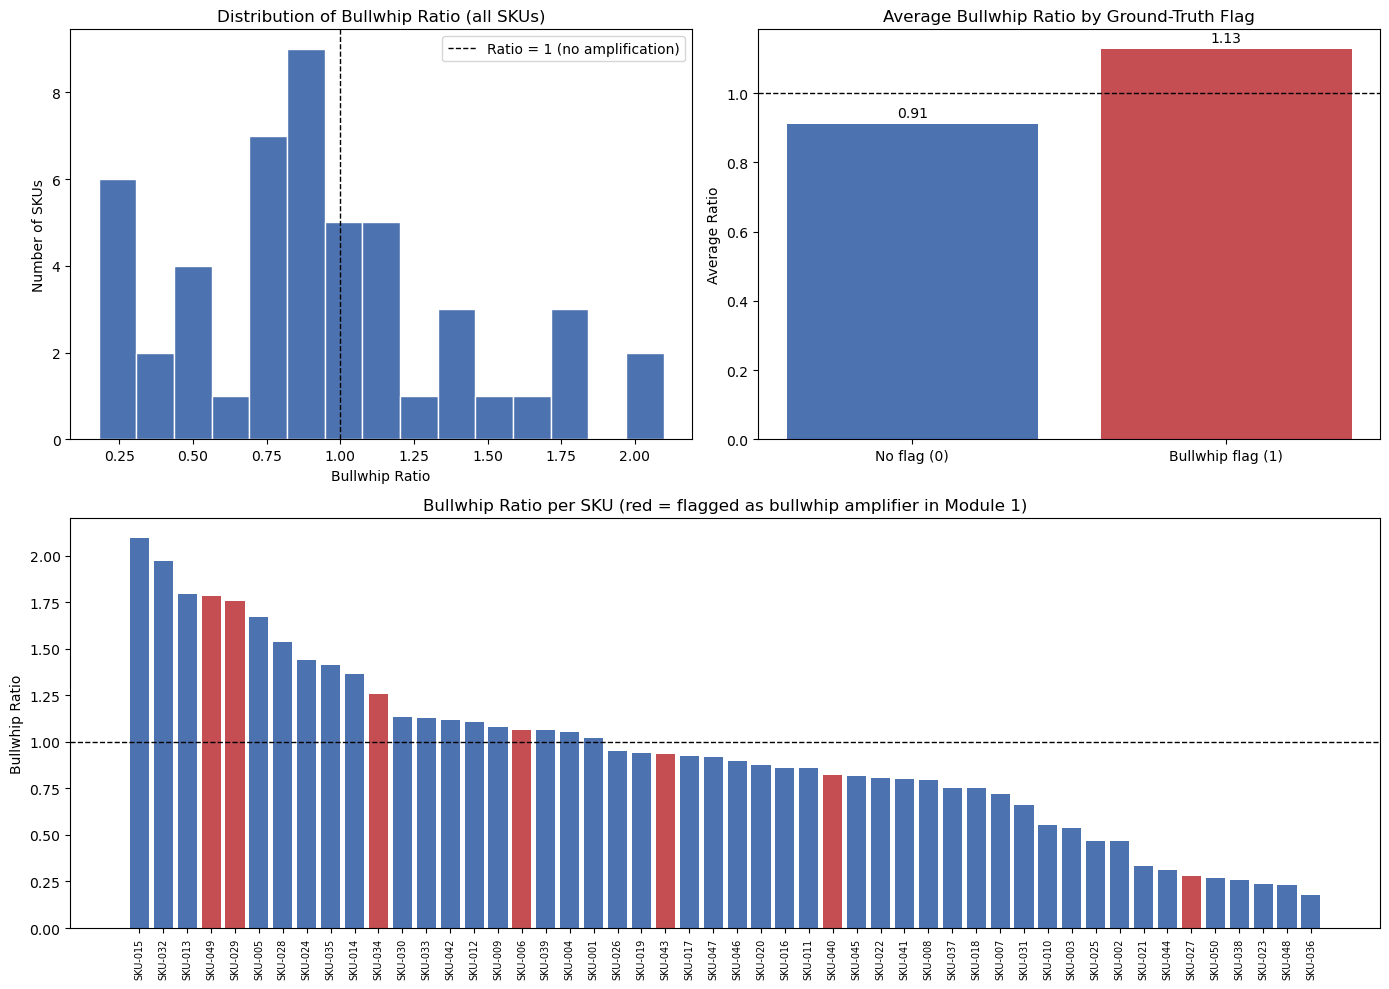

Chart saved to outputs/module5_bullwhip_analysis.png


In [13]:
# Cell 6 : Visualization

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

colors_flag = {0: "#4C72B0", 1: "#C44E52"}

# Plot 1 : Distribution of bullwhip ratio
ax1.hist(bullwhip["bullwhip_ratio"], bins=15, color="#4C72B0", edgecolor="white")
ax1.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Ratio = 1 (no amplification)")
ax1.set_title("Distribution of Bullwhip Ratio (all SKUs)")
ax1.set_xlabel("Bullwhip Ratio")
ax1.set_ylabel("Number of SKUs")
ax1.legend()

# Plot 2 : Average ratio by ground-truth flag
avg_by_flag = bullwhip.groupby("has_bullwhip")["bullwhip_ratio"].mean()
labels = ["No flag (0)", "Bullwhip flag (1)"]
ax2.bar(labels, avg_by_flag.values, color=[colors_flag[0], colors_flag[1]])
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Average Bullwhip Ratio by Ground-Truth Flag")
ax2.set_ylabel("Average Ratio")
for i, v in enumerate(avg_by_flag.values):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center")

# Plot 3 : Per-SKU ratio, sorted, colored by flag
bullwhip_sorted = bullwhip.sort_values("bullwhip_ratio", ascending=False)
bar_colors = [colors_flag[flag] for flag in bullwhip_sorted["has_bullwhip"]]

x = np.arange(len(bullwhip_sorted))
ax3.bar(x, bullwhip_sorted["bullwhip_ratio"], color=bar_colors)
ax3.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax3.set_xticks(x)
ax3.set_xticklabels(bullwhip_sorted["sku_id"], rotation=90, fontsize=7)
ax3.set_ylabel("Bullwhip Ratio")
ax3.set_title("Bullwhip Ratio per SKU (red = flagged as bullwhip amplifier in Module 1)")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "module5_bullwhip_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to outputs/module5_bullwhip_analysis.png")

## Cell 7 — Save to SQLite

Objective: Persist the bullwhip ratio table to the database for downstream use (Power BI dashboard, Module 6 financial layer).

In [14]:
# Cell 7 : Save to SQLite

bullwhip.to_sql("bullwhip_analysis", conn, if_exists="replace", index=False)

print(f"Table 'bullwhip_analysis' saved : {len(bullwhip)} rows")
print(f"Columns : {list(bullwhip.columns)}")

conn.close()
print("\nConnection closed.")

Table 'bullwhip_analysis' saved : 50 rows
Columns : ['sku_id', 'var_demand', 'var_forecast', 'bullwhip_ratio', 'Family', 'has_bullwhip']

Connection closed.
